In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [ ]:
pd.set_option('display.max_column',None)


In [ ]:
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
train_data['Duration'].value_counts()

,count
Duration,
2h 50m,550
1h 30m,386
2h 55m,337
2h 45m,337
2h 35m,329
...,...
30h 10m,1
31h 30m,1
42h 5m,1


In [ ]:
train_data.dropna(inplace=True)

In [ ]:
train_data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


eda


In [ ]:
import pandas as pd
train_data['Journey_day']=pd.to_datetime(train_data.Date_of_Journey,format='%d/%m/%Y').dt.day

In [ ]:
train_data['Journey_month']=pd.to_datetime(train_data['Date_of_Journey'],format='%d/%m/%Y').dt.month

In [ ]:
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [ ]:
#since we have turned date of journey into integeres we can drop it

train_data.drop(['Date_of_Journey'],axis=1,inplace=True)

In [ ]:
#time when plane leaves the gate is called departure time

In [ ]:
train_data['Dep_hour'] = pd.to_datetime(train_data['Dep_Time']).dt.hour
train_data['Dep_min'] = pd.to_datetime(train_data['Dep_Time']).dt.minute
train_data.drop(['Dep_Time'], axis=1, inplace=True)

KeyError: 'Dep_Time'

In [ ]:
train_data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [ ]:
#arrival time is when the plane enters the gate

In [ ]:
train_data['Arrival_hour'] = pd.to_datetime(train_data['Arrival_Time']).dt.hour
train_data['Arrival_min'] = pd.to_datetime(train_data['Arrival_Time']).dt.minute
train_data.drop(['Arrival_Time'], axis=1, inplace=True)

KeyError: 'Arrival_Time'

In [ ]:
train_data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [ ]:
def parse_duration(duration_str):
    parts = duration_str.split(' ')
    hours = 0
    minutes = 0
    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
        elif 'm' in part:
            minutes = int(part.replace('m', ''))
    return hours * 60 + minutes

train_data['Duration'] = train_data['Duration'].apply(parse_duration)

train_data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35


In [ ]:
train_data['Duration_hours'] = train_data['Duration'] // 60
train_data['Duration_minutes'] = train_data['Duration'] % 60
train_data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [ ]:
train_data.drop("Duration", axis=1,inplace=True)

In [ ]:
train_data.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


handling categorical data

In [ ]:
train_data['Airline'].value_counts()

,count
Airline,
Jet Airways,3849
IndiGo,2053
Air India,1752
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


In [ ]:
train_data.drop(["Duration"], axis=1,inplace=True)

KeyError: "['Duration'] not found in axis"

In [ ]:
train_data.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [ ]:
#from the above graph we can see jetairways have the highest price
#apart from the first one all the others have similar medium

In [ ]:
#airlines vs price


/tmp/ipython-input-1341276833.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Airline', y='Price', data=airline_prices, palette='viridis')


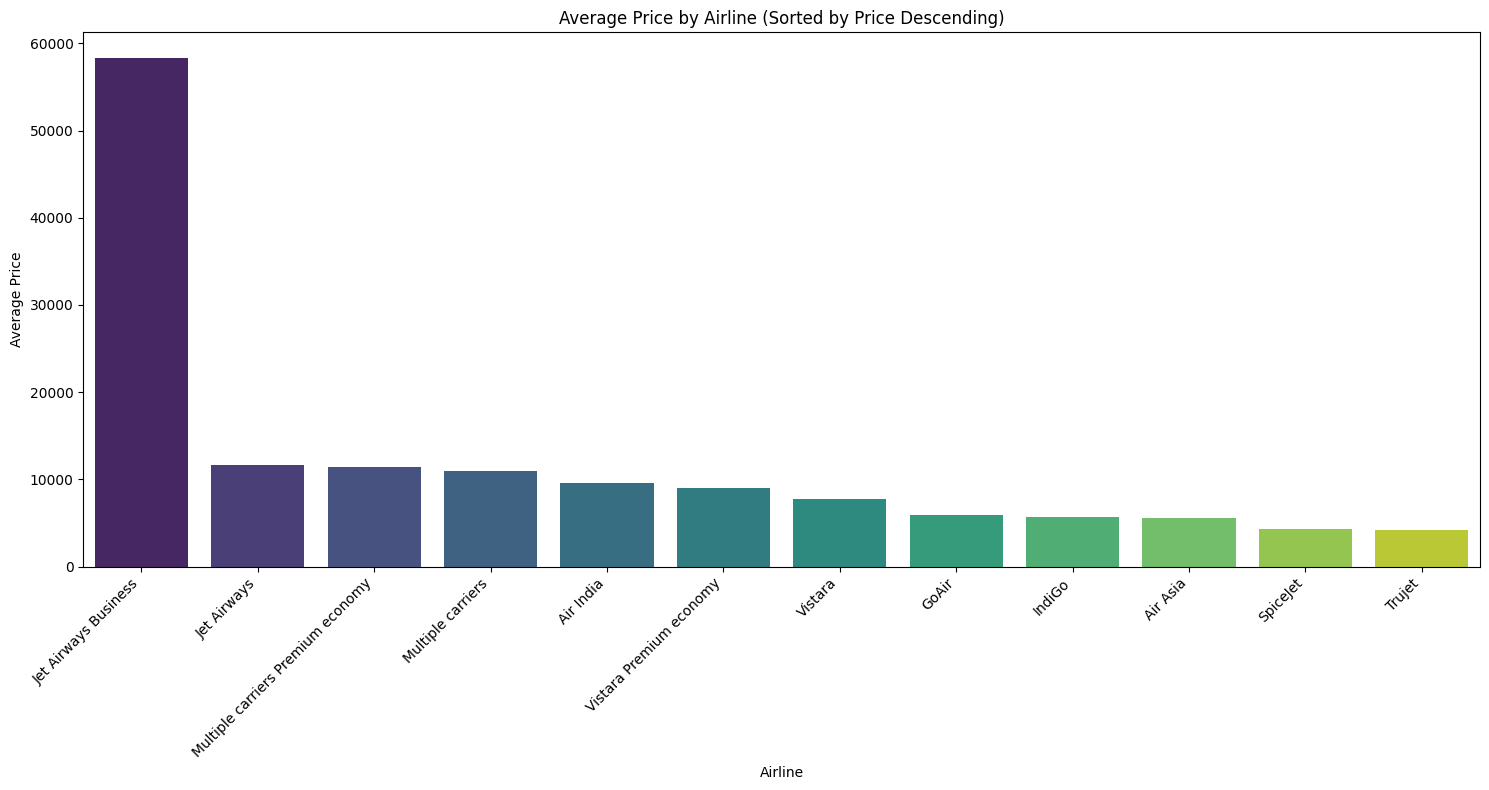

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Airline and calculate the mean Price, then sort in descending order
airline_prices = train_data.groupby('Airline')['Price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(x='Airline', y='Price', data=airline_prices, palette='viridis')
plt.title('Average Price by Airline (Sorted by Price Descending)')
plt.xlabel('Airline')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

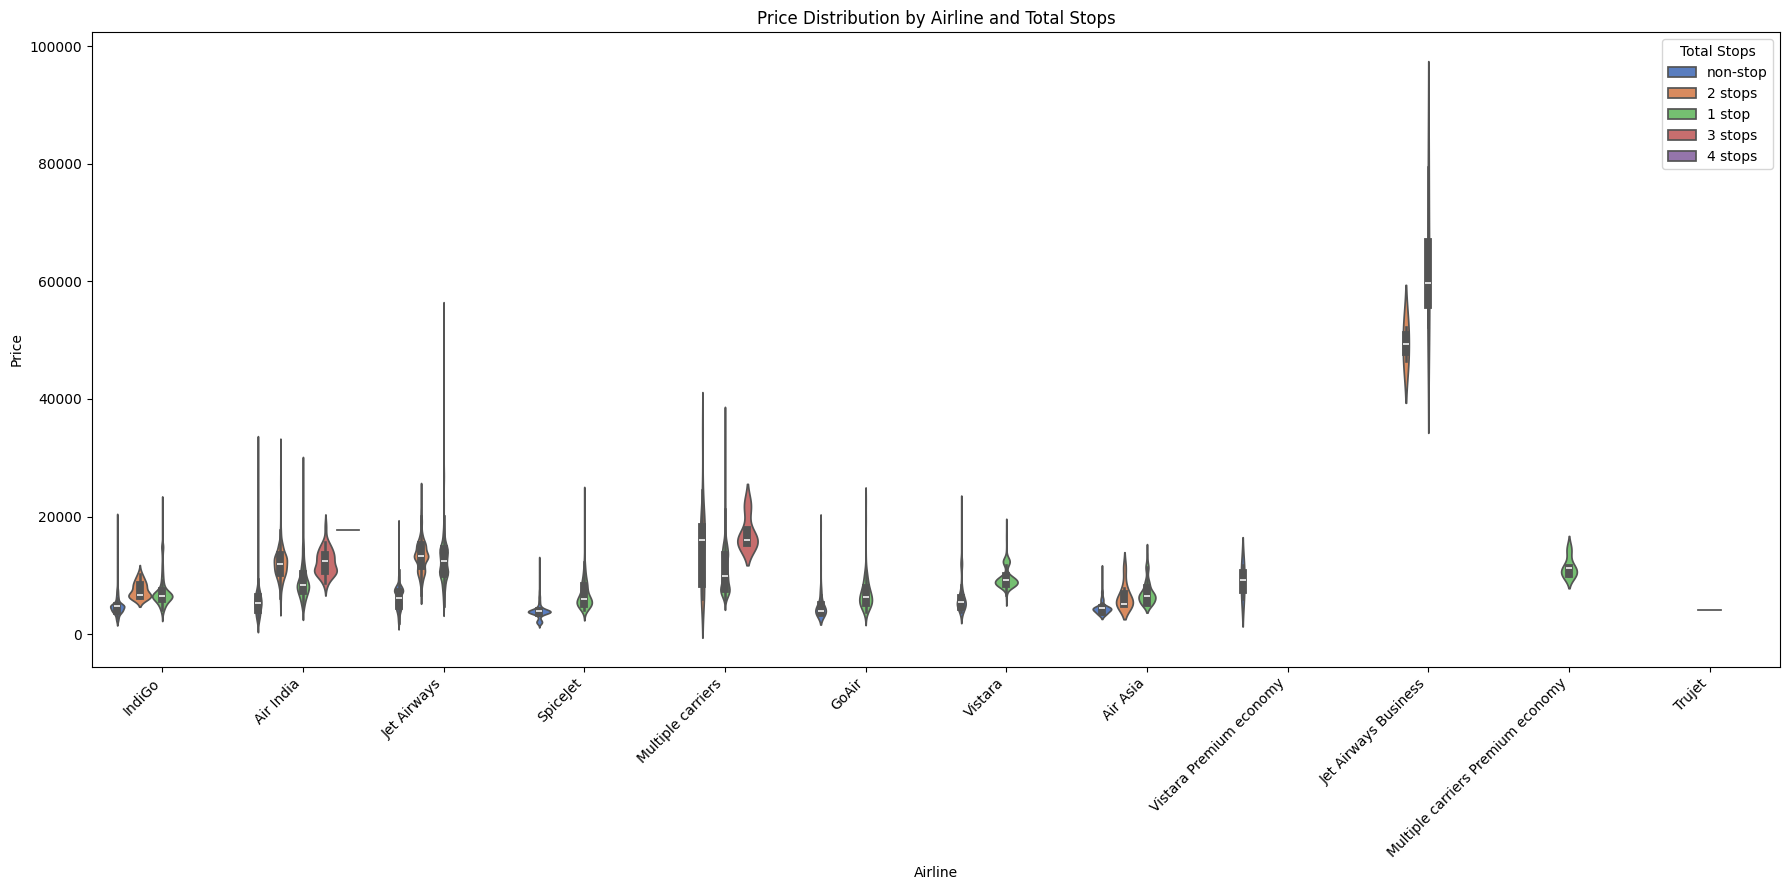

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a violin plot to compare price distribution for each airline, categorized by Total_Stops
plt.figure(figsize=(18, 9))
sns.violinplot(x="Airline", y="Price", hue="Total_Stops", data=train_data, palette="muted")
plt.title('Price Distribution by Airline and Total Stops')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total Stops')
plt.tight_layout()
plt.show()

In [ ]:
#As Airline is nominal category data we will perform one-hot encoding

Airline_dummies = train_data[['Airline']]
Airline_dummies = pd.get_dummies(Airline_dummies, drop_first=True)
Airline_dummies.head()

,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
train_data['Source'].value_counts()

,count
Source,
Delhi,4537
Kolkata,2871
Banglore,2197
Mumbai,697
Chennai,381


In [ ]:
#source vs price


/tmp/ipython-input-2920996785.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Source', y='Price', data=train_data, palette='coolwarm')


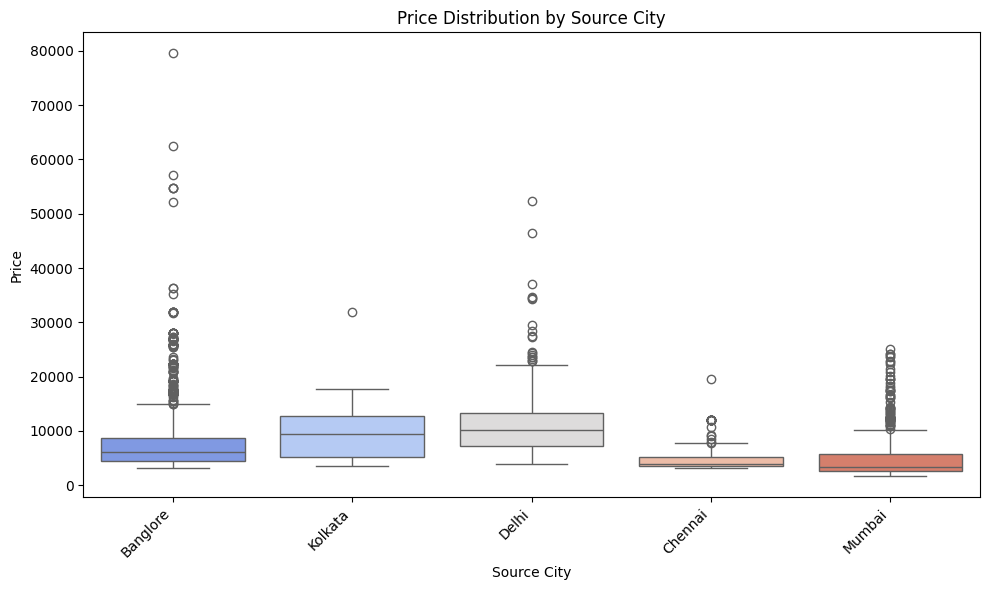

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Source', y='Price', data=train_data, palette='coolwarm')
plt.title('Price Distribution by Source City')
plt.xlabel('Source City')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#we will do on hot coding for source
Source_dummies = train_data[['Source']]
Source_dummies = pd.get_dummies(Source_dummies, drop_first=True)
Source_dummies.head()

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


In [ ]:
train_data["Destination"].value_counts()


,count
Destination,
Cochin,4537
Banglore,2871
Delhi,1265
New Delhi,932
Hyderabad,697
Kolkata,381


In [ ]:
#destination is a nominal data we will perform onhotcoding
Destination=train_data[["Destination"]]
Destination=pd.get_dummies(Destination,drop_first=True)
Destination.head()

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [ ]:
train_data["Route"]

,Route
0,BLR → DEL
1,CCU → IXR → BBI → BLR
2,DEL → LKO → BOM → COK
3,CCU → NAG → BLR
4,BLR → NAG → DEL
...,...
10678,CCU → BLR
10679,CCU → BLR
10680,BLR → DEL
10681,BLR → DEL


In [ ]:
#additional info contain almost no info , route and total stops are related to each other'

train_data.drop(["Route", "Additional_Info"], axis=1, inplace=True)

KeyError: "['Route', 'Additional_Info'] not found in axis"

In [ ]:
train_data['Total_Stops'].value_counts()

,count
Total_Stops,
1 stop,5625
non-stop,3491
2 stops,1520
3 stops,45
4 stops,1


In [ ]:
#as this is the case of ordinal categorical type we perform labeencoder
#here values are assigned to corrospondoing keys


In [ ]:
train_data.replace({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}, inplace=True)
train_data.head()

/tmp/ipython-input-3601729818.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data.replace({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}, inplace=True)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0.0,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2.0,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2.0,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1.0,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1.0,No info,13302


In [ ]:
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0.0,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2.0,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2.0,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1.0,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1.0,No info,13302


In [ ]:
# Columns to process and drop
cols_to_process = ['Airline', 'Source', 'Destination']
cols_to_drop_final = ['Airline', 'Source', 'Destination', 'Route', 'Additional_Info']

# Create dummy variables for existing columns
processed_dfs = []
for col in cols_to_process:
    if col in train_data.columns:
        dummy_df = pd.get_dummies(train_data[[col]], drop_first=True)
        processed_dfs.append(dummy_df)
    else:
        print(f"Warning: Column '{col}' not found in train_data. Skipping one-hot encoding.")

# Concatenate dummy variables if any were created
if processed_dfs:
    train_data = pd.concat([train_data] + processed_dfs, axis=1)

# Drop original columns that exist and were intended to be dropped
for col in cols_to_drop_final:
    if col in train_data.columns:
        train_data.drop(col, axis=1, inplace=True)
    else:
        print(f"Warning: Column '{col}' not found in train_data. Skipping drop operation.")

train_data.head()

,Date_of_Journey,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,24/03/2019,22:20,01:10 22 Mar,2h 50m,non-stop,3897,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,1/05/2019,05:50,13:15,7h 25m,2 stops,7662,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,9/06/2019,09:25,04:25 10 Jun,19h,2 stops,13882,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
3,12/05/2019,18:05,23:30,5h 25m,1 stop,6218,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,01/03/2019,16:50,21:35,4h 45m,1 stop,13302,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
train_data.shape

(10683, 26)

Test set

In [ ]:
test_set=pd.read_excel(r"Test_set.xlsx")

In [ ]:
test_set.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [ ]:
test_set.info()
print("\nMissing values before dropping:\n")
print(test_set.isnull().sum())
test_set.dropna(inplace=True)
print("\nMissing values after dropping:\n")
print(test_set.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB

Missing values before dropping:

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64

Missing values after dropping:

Airline            0

In [ ]:
# The 'Date_of_Journey' column has already been processed, and 'Journey_day' and 'Journey_month' have been extracted.
# The original 'Date_of_Journey' column no longer exists.

test_set.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Journey_day,Journey_month
0,Jet Airways,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info,6,6
1,IndiGo,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info,12,5
2,Jet Airways,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included,21,5
3,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info,21,5
4,Air Asia,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info,24,6


## Extract time features from Dep_Time

In [ ]:
test_set['Dep_hour'] = pd.to_datetime(test_set['Dep_Time']).dt.hour
test_set['Dep_min'] = pd.to_datetime(test_set['Dep_Time']).dt.minute
test_set.drop(['Dep_Time'], axis=1, inplace=True)
test_set.head()

/tmp/ipython-input-4022909615.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_set['Dep_hour'] = pd.to_datetime(test_set['Dep_Time']).dt.hour
/tmp/ipython-input-4022909615.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_set['Dep_min'] = pd.to_datetime(test_set['Dep_Time']).dt.minute


,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Journey_day,Journey_month,Dep_hour,Dep_min
0,Jet Airways,Delhi,Cochin,DEL → BOM → COK,04:25 07 Jun,10h 55m,1 stop,No info,6,6,17,30
1,IndiGo,Kolkata,Banglore,CCU → MAA → BLR,10:20,4h,1 stop,No info,12,5,6,20
2,Jet Airways,Delhi,Cochin,DEL → BOM → COK,19:00 22 May,23h 45m,1 stop,In-flight meal not included,21,5,19,15
3,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,21:00,13h,1 stop,No info,21,5,8,0
4,Air Asia,Banglore,Delhi,BLR → DEL,02:45 25 Jun,2h 50m,non-stop,No info,24,6,23,55


In [ ]:
test_set.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Journey_day,Journey_month
0,Jet Airways,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info,6,6
1,IndiGo,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info,12,5
2,Jet Airways,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included,21,5
3,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info,21,5
4,Air Asia,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info,24,6


## Extract time features from Arrival_Time

In [ ]:
# The 'Arrival_Time' column has already been processed, and 'Arrival_hour' and 'Arrival_min' have been extracted.
# The original 'Arrival_Time' column no longer exists.

## Process Duration column

In [ ]:
# The 'Duration' column has already been processed, and 'Duration_hours' and 'Duration_minutes' have been extracted.
# The original 'Duration' column no longer exists.

## Encode Total_Stops

In [ ]:
test_set.replace({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}, inplace=True)
test_set.head()

/tmp/ipython-input-555879994.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_set.replace({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}, inplace=True)


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_minutes
0,Jet Airways,Delhi,Cochin,DEL → BOM → COK,1,No info,6,6,17,30,4,25,10,55
1,IndiGo,Kolkata,Banglore,CCU → MAA → BLR,1,No info,12,5,6,20,10,20,4,0
2,Jet Airways,Delhi,Cochin,DEL → BOM → COK,1,In-flight meal not included,21,5,19,15,19,0,23,45
3,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,1,No info,21,5,8,0,21,0,13,0
4,Air Asia,Banglore,Delhi,BLR → DEL,0,No info,24,6,23,55,2,45,2,50


In [ ]:
# fijding correlation between dependant and independant attributes


/tmp/ipython-input-3379779592.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_data_corr['Dep_hour'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.hour
/tmp/ipython-input-3379779592.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_data_corr['Dep_min'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.minute
/tmp/ipython-input-3379779592.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_data_corr['Arrival_hour'] = pd.to_datetime(train_data_corr['Arrival_Time']).dt.hour
/tmp/ipython-input-3379779592.py:24: UserWarning: Could not infer format, so

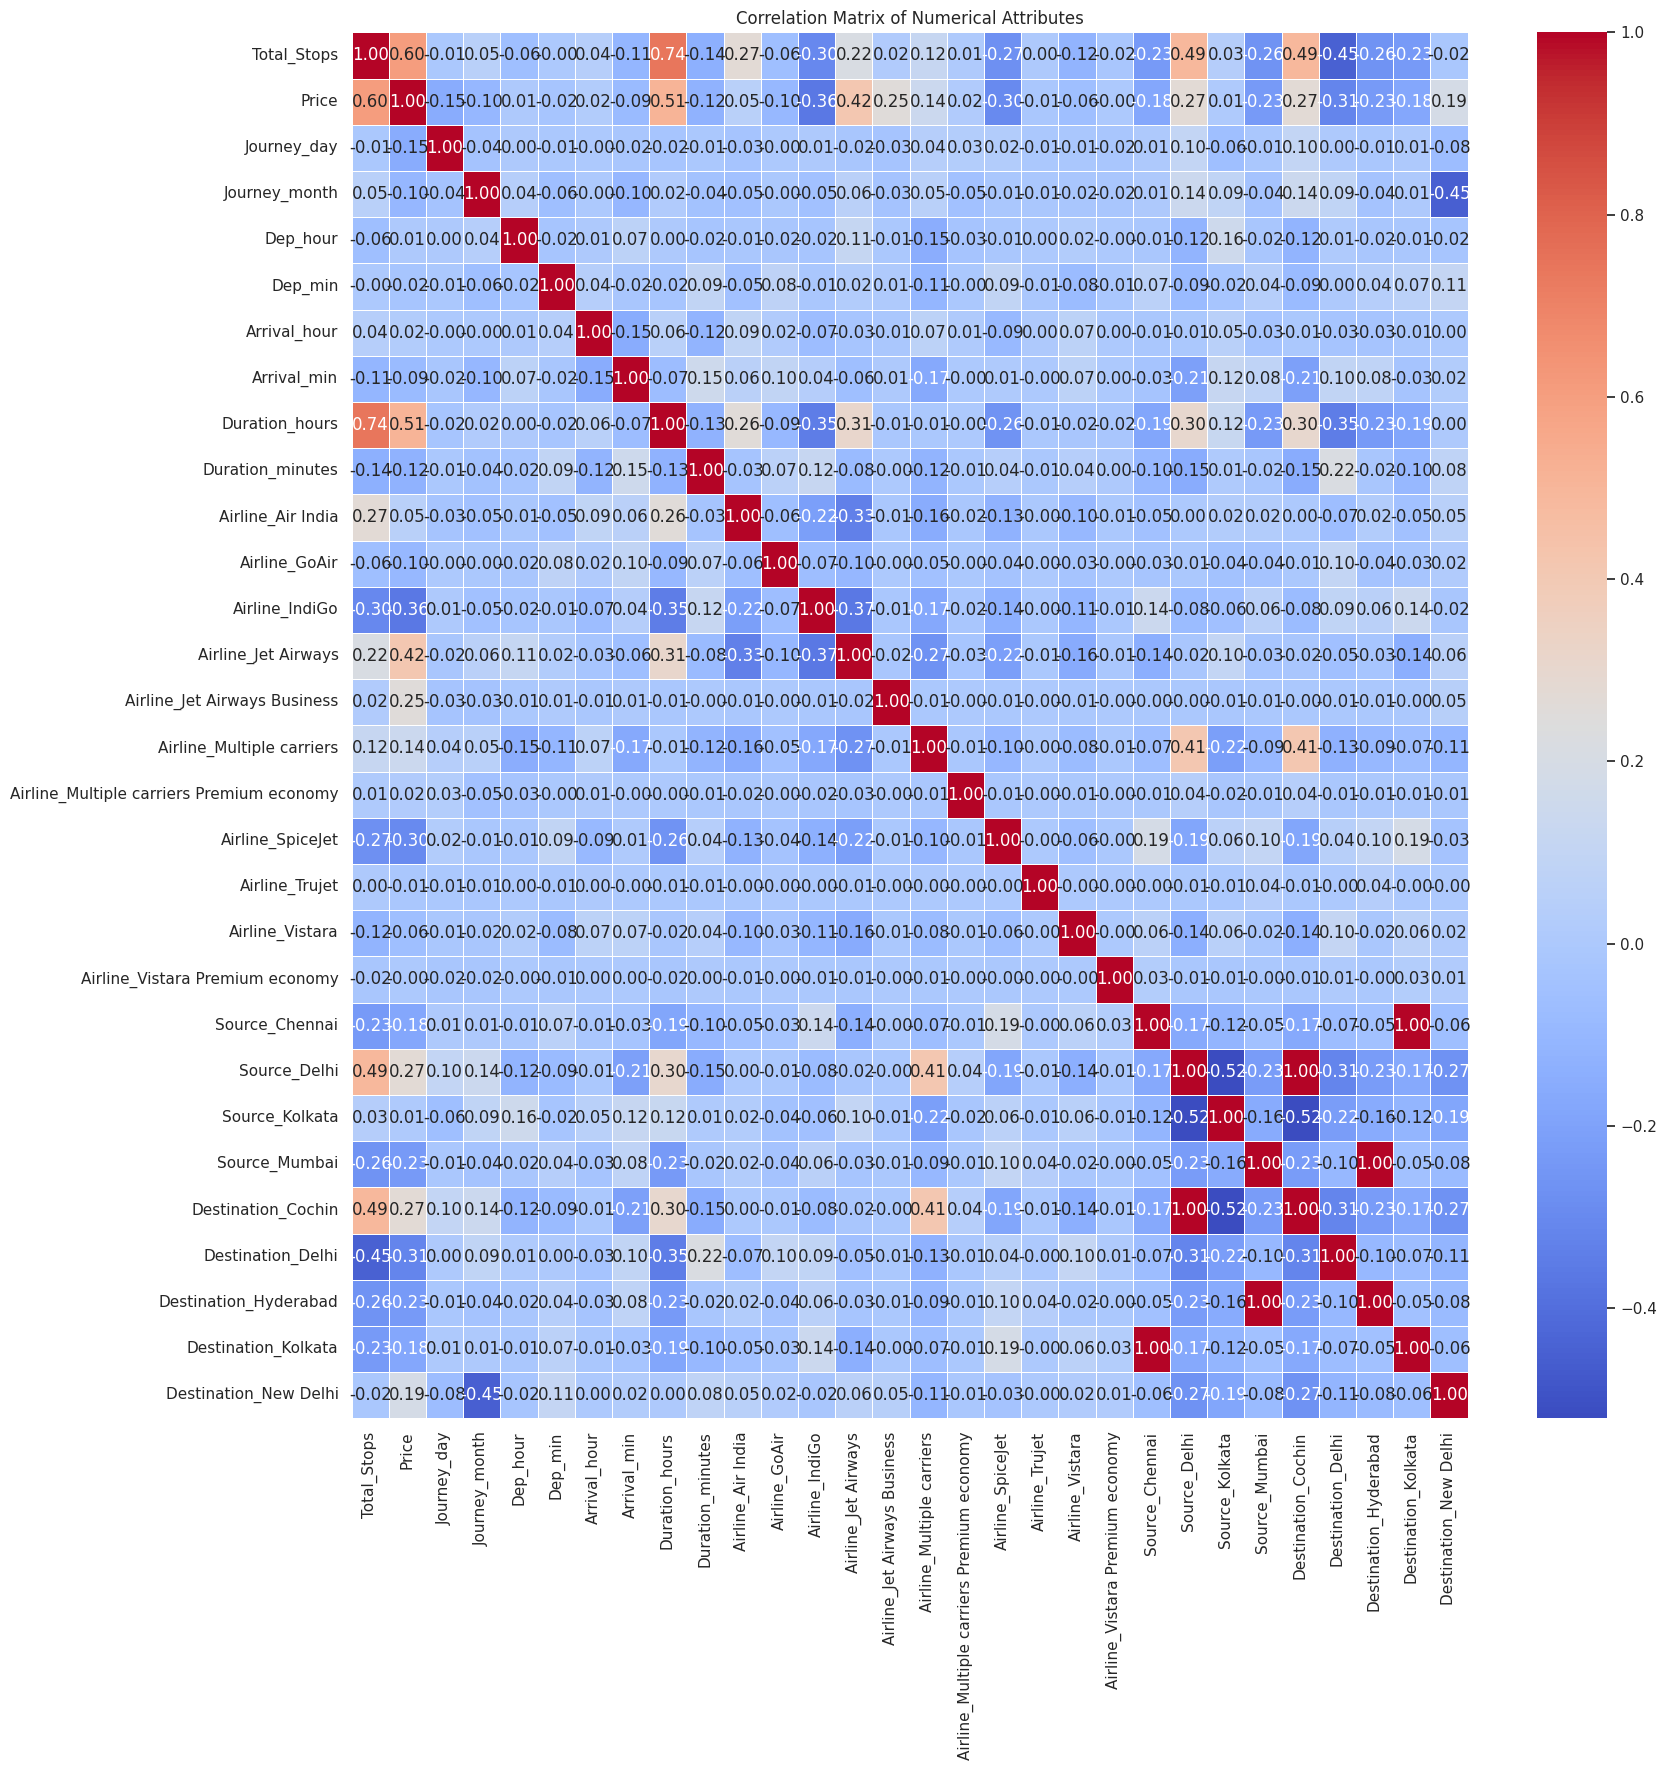

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-load train_data to ensure a consistent starting point for correlation analysis
# Assuming original data was loaded from Data_Train.xlsx as in cell iBnrt4L2RIJn
train_data_corr = pd.read_excel(r"Data_Train.xlsx")

# Drop NA values as done in SBeI1A7zTNy3
train_data_corr.dropna(inplace=True)

# Process Date_of_Journey as in L8AnaqUdTOBk, tJJJ_Sh0T8eJ, gx8MzUJ9zPPo
train_data_corr['Journey_day'] = pd.to_datetime(train_data_corr.Date_of_Journey, format='%d/%m/%Y').dt.day
train_data_corr['Journey_month'] = pd.to_datetime(train_data_corr.Date_of_Journey, format='%d/%m/%Y').dt.month
train_data_corr.drop(['Date_of_Journey'], axis=1, inplace=True)

# Process Dep_Time as in 9e08ef0d
train_data_corr['Dep_hour'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.hour
train_data_corr['Dep_min'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.minute
train_data_corr.drop(['Dep_Time'], axis=1, inplace=True)

# Process Arrival_Time as in a852d06d
train_data_corr['Arrival_hour'] = pd.to_datetime(train_data_corr['Arrival_Time']).dt.hour
train_data_corr['Arrival_min'] = pd.to_datetime(train_data_corr['Arrival_Time']).dt.minute
train_data_corr.drop(['Arrival_Time'], axis=1, inplace=True)

# Process Duration as in E1pHeJcGzP1f, yaMgZ5gg0oFZ, 7uWbFb540oHP
def parse_duration(duration_str):
    parts = duration_str.split(' ')
    hours = 0
    minutes = 0
    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
        elif 'm' in part:
            minutes = int(part.replace('m', ''))
    return hours * 60 + minutes

train_data_corr['Duration_minutes_total'] = train_data_corr['Duration'].apply(parse_duration)
train_data_corr['Duration_hours'] = train_data_corr['Duration_minutes_total'] // 60
train_data_corr['Duration_minutes'] = train_data_corr['Duration_minutes_total'] % 60
train_data_corr.drop(['Duration', 'Duration_minutes_total'], axis=1, inplace=True)

# Encode Total_Stops as in ruFXIK7MapWj
train_data_corr.replace({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}, inplace=True)

# One-hot encode Airline, Source, Destination as in WYJXamCRDUGB, 83863f42, FOPBlNJZGZKm
Airline_dummies = pd.get_dummies(train_data_corr['Airline'], prefix='Airline', drop_first=True)
Source_dummies = pd.get_dummies(train_data_corr['Source'], prefix='Source', drop_first=True)
Destination_dummies = pd.get_dummies(train_data_corr['Destination'], prefix='Destination', drop_first=True)

# Concatenate all dummy variables and drop original categorical columns
train_data_corr = pd.concat([train_data_corr, Airline_dummies, Source_dummies, Destination_dummies], axis=1)
train_data_corr.drop(['Airline', 'Source', 'Destination', 'Route', 'Additional_Info'], axis=1, inplace=True)

# Now calculate the correlation matrix
plt.figure(figsize=(18, 18))
corr_matrix = train_data_corr.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Attributes')
plt.show()

In [ ]:
#important features using extratreelearn

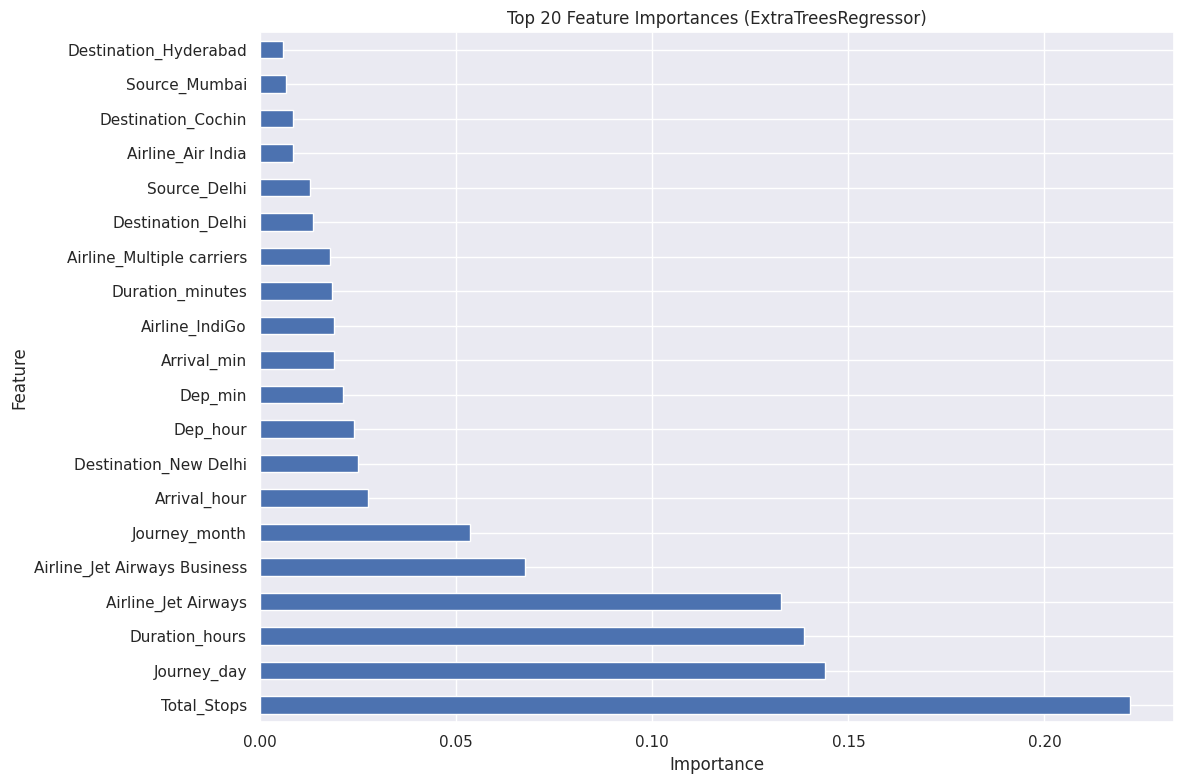

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

X = train_data_corr.drop('Price', axis=1)  # Features
y = train_data_corr['Price']              # Target

# Initialize ExtraTreesRegressor
model = ExtraTreesRegressor()

# Fit the model
model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Plot feature importances
plt.figure(figsize=(12, 8))
feature_importances.nlargest(20).plot(kind='barh') # Display top 20 features
plt.title('Top 20 Feature Importances (ExtraTreesRegressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Fitting a model using random forest

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Re-load train_data to ensure a consistent starting point for correlation analysis
train_data_corr = pd.read_excel(r"Data_Train.xlsx")

# Drop NA values as done in SBeI1A7zTNy3
train_data_corr.dropna(inplace=True)

# Process Date_of_Journey as in L8AnaqUdTOBk, tJJJ_Sh0T8eJ, gx8MzUJ9zPPo
train_data_corr['Journey_day'] = pd.to_datetime(train_data_corr.Date_of_Journey, format='%d/%m/%Y').dt.day
train_data_corr['Journey_month'] = pd.to_datetime(train_data_corr.Date_of_Journey, format='%d/%m/%Y').dt.month
train_data_corr.drop(['Date_of_Journey'], axis=1, inplace=True)

# Process Dep_Time as in 9e08ef0d
train_data_corr['Dep_hour'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.hour
train_data_corr['Dep_min'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.minute
train_data_corr.drop(['Dep_Time'], axis=1, inplace=True)

# Process Arrival_Time as in a852d06d
train_data_corr['Arrival_hour'] = pd.to_datetime(train_data_corr['Arrival_Time']).dt.hour
train_data_corr['Arrival_min'] = pd.to_datetime(train_data_corr['Arrival_Time']).dt.minute
train_data_corr.drop(['Arrival_Time'], axis=1, inplace=True)

# Process Duration as in E1pHeJcGzP1f, yaMgZ5gg0oFZ, 7uWbFb540oHP
def parse_duration(duration_str):
    parts = duration_str.split(' ')
    hours = 0
    minutes = 0
    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
        elif 'm' in part:
            minutes = int(part.replace('m', ''))
    return hours * 60 + minutes

train_data_corr['Duration_minutes_total'] = train_data_corr['Duration'].apply(parse_duration)
train_data_corr['Duration_hours'] = train_data_corr['Duration_minutes_total'] // 60
train_data_corr['Duration_minutes'] = train_data_corr['Duration_minutes_total'] % 60
train_data_corr.drop(['Duration', 'Duration_minutes_total'], axis=1, inplace=True)

# Encode Total_Stops as in ruFXIK7MapWj
train_data_corr.replace({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}, inplace=True)

# One-hot encode Airline, Source, Destination as in WYJXamCRDUGB, 83863f42, FOPBlNJZGZKm
Airline_dummies = pd.get_dummies(train_data_corr['Airline'], prefix='Airline', drop_first=True)
Source_dummies = pd.get_dummies(train_data_corr['Source'], prefix='Source', drop_first=True)
Destination_dummies = pd.get_dummies(train_data_corr['Destination'], prefix='Destination', drop_first=True)

# Concatenate all dummy variables and drop original categorical columns
train_data_corr = pd.concat([train_data_corr, Airline_dummies, Source_dummies, Destination_dummies], axis=1)
train_data_corr.drop(['Airline', 'Source', 'Destination', 'Route', 'Additional_Info'], axis=1, inplace=True)

X = train_data_corr.drop('Price', axis=1)  # Features
y = train_data_corr['Price']              # Target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

/tmp/ipython-input-21740278.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_data_corr['Dep_hour'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.hour
/tmp/ipython-input-21740278.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_data_corr['Dep_min'] = pd.to_datetime(train_data_corr['Dep_Time']).dt.minute
/tmp/ipython-input-21740278.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_data_corr['Arrival_hour'] = pd.to_datetime(train_data_corr['Arrival_Time']).dt.hour
/tmp/ipython-input-21740278.py:22: UserWarning: Could not infer format, so each el

In [ ]:
from sklearn.ensemble import RandomForestRegressor
reg_rf=RandomForestRegressor()
reg_rf.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred=reg_rf.predict(X_test)

In [ ]:
reg_rf.score(X_train,y_train)

0.9536100960829008

In [ ]:
reg_rf.score(X_test,y_test)

0.7972568601470726

In [ ]:
reg_rf.score(X_test,y_test)

0.7972568601470726

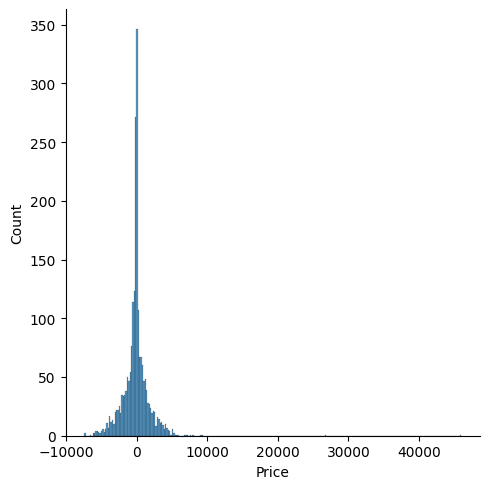

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(y_test-y_pred)
plt.show()

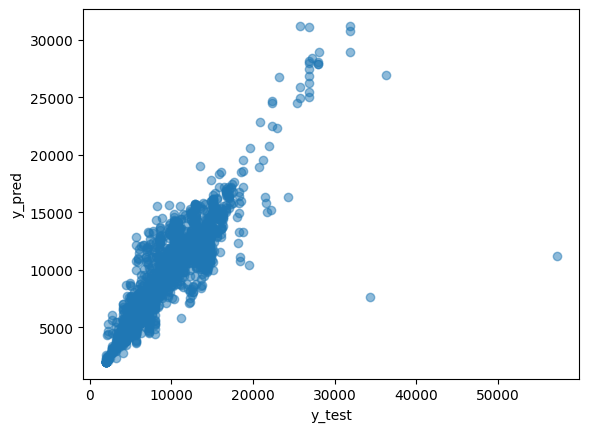

In [ ]:
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

In [ ]:
from sklearn import metrics

In [ ]:
from sklearn import metrics
import numpy as np

# Calculate MAE, MSE, RMSE
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 1173.98
Mean Squared Error (MSE): 4371559.00
Root Mean Squared Error (RMSE): 2090.83


In [ ]:
metrics.r2_score(y_test,y_pred)

0.7972568601470726

Hyperparameter tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(5, 30, num = 6)]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 15, 100]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 5, 10]

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

print(random_grid)

{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], 'max_features': ['auto', 'sqrt'], 'max_depth': [5, 10, 15, 20, 25, 30], 'min_samples_split': [2, 5, 10, 15, 100], 'min_samples_leaf': [1, 2, 5, 10]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
# Number of features to consider at every split
max_features = ['sqrt'] # Removed 'auto' as it's no longer supported
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(5, 30, num = 6)]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 15, 100]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 5, 10]

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

# Use the random grid to search for best hyperparameters
# First create the base model to tune
rf = RandomForestRegressor()

# Random search of parameters, using 5 fold cross validation,
# search across 100 different combinations
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, scoring='neg_mean_squared_error', n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = 1)

# Fit the random search model
rf_random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   8.0s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   7.0s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   7.1s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   7.6s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   6.7s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   6.7s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   5.7s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_esti

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [ ]:
print(rf_random.best_params_)

{'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}


In [ ]:
#random search using 5 fold cross validation
#search across 100 different combo
rf_random= RandomizedSearchCV(estimator= rf, param_distributions =random_grid, scoring = 'neg_mean_squared_error',n_iter=10, cv= 5,verbose=2, random_state=42,n_jobs=1)

In [ ]:
rf_random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   6.7s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   7.9s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   9.1s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   6.6s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   7.4s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   5.6s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   6.5s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_esti

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [ ]:
rf_random.best_params_

{'n_estimators': 300,
 'min_samples_split': 15,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30}

In [ ]:
rf_random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   8.8s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   7.6s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   6.6s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   7.4s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   6.7s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   6.5s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   5.6s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_esti

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [ ]:
prediction=rf_random.predict(X_test)

In [ ]:
rf_random.best_params_

{'n_estimators': 300,
 'min_samples_split': 15,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30}

In [ ]:
prediction=rf_random.predict(X_test)

/tmp/ipython-input-3865557949.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-prediction)


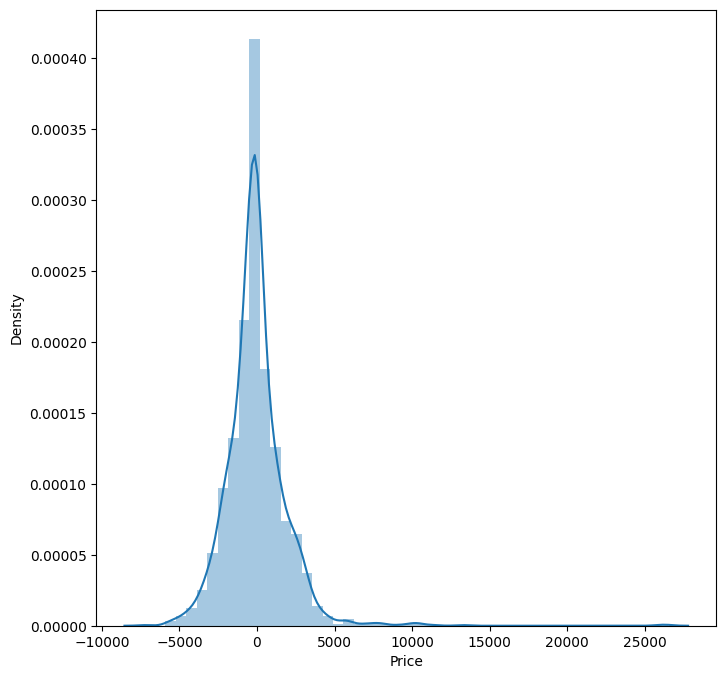

In [ ]:
plt.figure(figsize=(8,8))
sns.distplot(y_test-prediction)
plt.show()

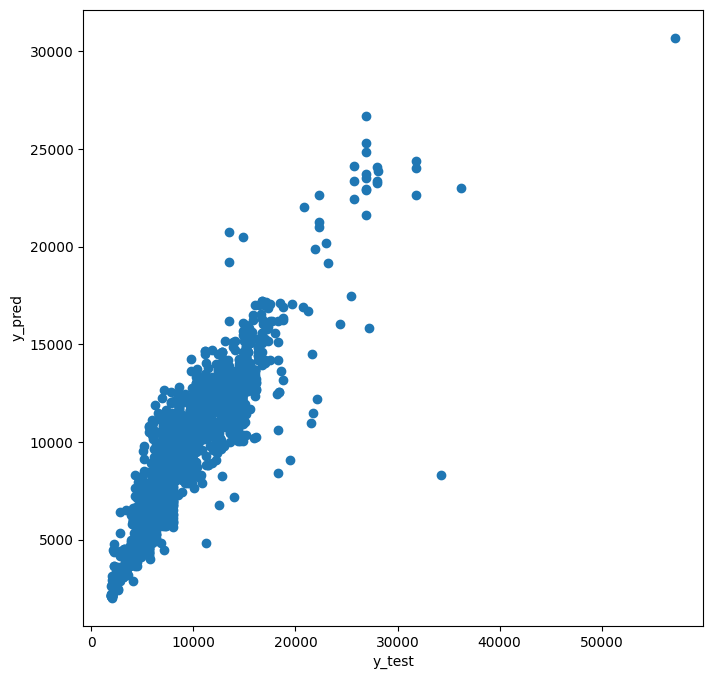

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test,prediction)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

In [ ]:
rf_random.best_params_

{'n_estimators': 300,
 'min_samples_split': 15,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30}

In [ ]:
prediction=rf_random.predict(X_test)

In [ ]:
plt.figure(figsize=(8,8))
sns.displot(y_test-prediction)
plt.show()

In [ ]:
from sklearn import metrics
import numpy as np

# Calculate MAE, MSE, RMSE
mae = metrics.mean_absolute_error(y_test, prediction)
mse = metrics.mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R2 Score: {metrics.r2_score(y_test, prediction):.2f}')

Mean Absolute Error (MAE): 1289.07
Mean Squared Error (MSE): 3919063.37
Root Mean Squared Error (RMSE): 1979.66
R2 Score: 0.82


save the model to reuse it again

In [ ]:
import pickle
#open the file where you ant to store the data
file=open('flight_rf.pkl','wb')

#dump information to the file
pickle.dump(reg_rf,file)

In [ ]:
model=open('flight_rf.pkl','rb')
forest=pickle.load(model)

In [ ]:
y_prediction=forest.predict(X_test)

In [ ]:
metrics.r2_score(y_test,y_prediction)

0.7972568601470726

In [ ]:
y_prediction=forest.predict(X_test)

In [ ]:
metrics.r2_score(y_test,y_prediction)

0.7972568601470726